# 03 Model Selection

## XGBoost Classifier

## Daten laden

In [16]:
import pandas as pd
from pathlib import Path

PROCESSED_DIR = Path("../../data/processed")
RESULTS_DIR = Path("../../results")
TABLE_DIR = RESULTS_DIR / "tables"

TABLE_DIR.mkdir(parents=True, exist_ok=True)

train_data = pd.read_csv(PROCESSED_DIR / "train_data.csv")
test_data = pd.read_csv(PROCESSED_DIR / "test_data.csv")

with open(PROCESSED_DIR / "feature_columns.txt", "r", encoding="utf-8") as f:
    feature_cols = [line.strip() for line in f]

print("Train data:", train_data.shape)
print("Test data:", test_data.shape)
print("Anzahl Features:", len(feature_cols))

Train data: (5867, 563)
Test data: (1485, 563)
Anzahl Features: 561


## X, y und groups erstellen

In [17]:
target_col = "activity"
group_col = "subject"

X_train = train_data[feature_cols]
y_train = train_data[target_col]
groups_train = train_data[group_col]

X_test = test_data[feature_cols]
y_test = test_data[target_col]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("groups_train:", groups_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (5867, 561)
y_train: (5867,)
groups_train: (5867,)
X_test: (1485, 561)
y_test: (1485,)


## Labels für XGBoost kodieren

In [18]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Klassen:")
for ordinal, encoded in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(encoded, "=", ordinal)

Klassen:
0 = LAYING
1 = SITTING
2 = STANDING
3 = WALKING
4 = WALKING_DOWNSTAIRS
5 = WALKING_UPSTAIRS


## XGBClassifier definieren

In [19]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    n_estimators=350,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1
)

xgb_model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

## Cross-Validation mit GroupKFold

In [20]:
from sklearn.model_selection import GroupKFold, cross_validate

cv = GroupKFold(n_splits=5)

xgb_cv_scores = cross_validate(
    xgb_model,
    X_train,
    y_train_encoded,
    groups=groups_train,
    cv=cv,
    scoring="accuracy",
    return_train_score=True,
    n_jobs=-1
)

xgb_cv_scores

{'fit_time': array([66.1309309 , 73.35091805, 73.81765246, 65.51297283, 73.67952418]),
 'score_time': array([0.05679297, 0.06253052, 0.06255531, 0.06075835, 0.05145478]),
 'test_score': array([0.93572779, 0.92600897, 0.9513633 , 0.90066225, 0.81267739]),
 'train_score': array([1., 1., 1., 1., 1.])}

## Ergebnisse zusammenfassen

In [21]:
xgb_result = pd.DataFrame({
    "model": ["XGBClassifier"],
    "mean_cv_accuracy": [xgb_cv_scores["test_score"].mean()],
    "std_cv_accuracy": [xgb_cv_scores["test_score"].std()],
    "mean_cv_error": [1 - xgb_cv_scores["test_score"].mean()],
    "mean_train_accuracy": [xgb_cv_scores["train_score"].mean()],
    "mean_fit_time": [xgb_cv_scores["fit_time"].mean()],
    "mean_score_time": [xgb_cv_scores["score_time"].mean()]
})

xgb_result

,model,mean_cv_accuracy,std_cv_accuracy,mean_cv_error,mean_train_accuracy,mean_fit_time,mean_score_time
0,XGBClassifier,0.905288,0.049147,0.094712,1.0,70.4984,0.058818


## Ergebnis speichern

In [22]:
xgb_result.to_csv(TABLE_DIR / "xgb_cv_result.csv", index=False)

print("Gespeichert:", TABLE_DIR / "xgb_cv_result.csv")

Gespeichert: ..\..\results\tables\xgb_cv_result.csv


In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

# Modell auf Trainingsdaten trainieren
xgb_model.fit(X_train, y_train_encoded)

# Vorhersage auf Testdaten
y_pred_encoded = xgb_model.predict(X_test)

# Zurück zu ursprünglichen Klassennamen
y_pred = label_encoder.inverse_transform(y_pred_encoded)

# Accuracy und Test Error
test_accuracy = accuracy_score(y_test, y_pred)
test_error = 1 - test_accuracy

print("Test Accuracy:", round(test_accuracy, 4))
print("Test Error:", round(test_error, 4))

# Klassifikationsbericht
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9549
Test Error: 0.0451
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       293
           SITTING       0.90      0.85      0.88       264
          STANDING       0.87      0.91      0.89       283
           WALKING       1.00      1.00      1.00       229
WALKING_DOWNSTAIRS       0.99      0.99      0.99       200
  WALKING_UPSTAIRS       1.00      1.00      1.00       216

          accuracy                           0.95      1485
         macro avg       0.96      0.96      0.96      1485
      weighted avg       0.96      0.95      0.95      1485



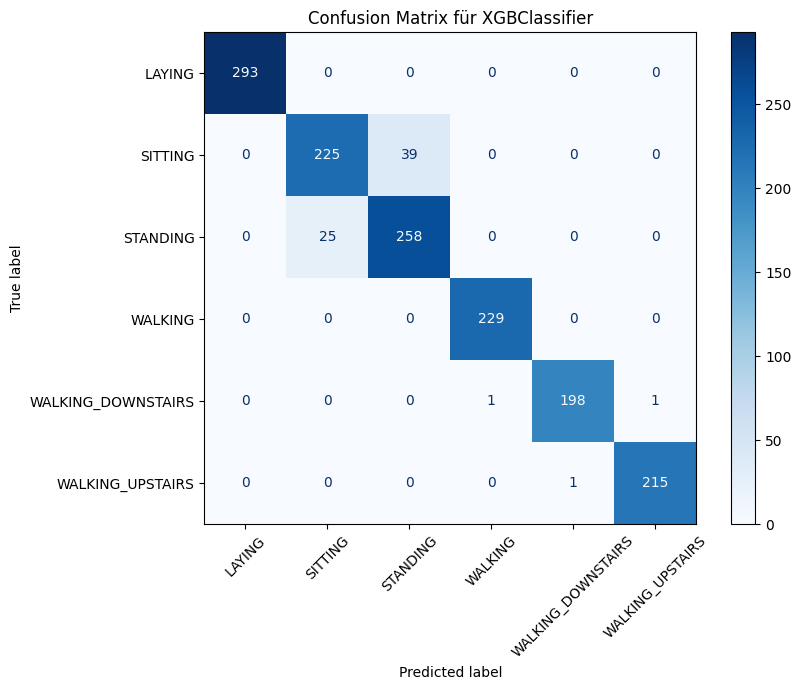

In [24]:
labels = label_encoder.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", values_format="d")

plt.title("Confusion Matrix für XGBClassifier")
plt.tight_layout()
plt.show()